# Extended Data Figure 7 — Leave-one-out drug target enrichment

Sensitivity analysis for drug-target enrichment:

**(a)** Leave-one-out by **therapeutic area (TA)** — OR (95 % CI) for approved targets
after excluding each TA from the enrichment calculation.  
**(b)** Leave-one-out by **target class** — OR (95 % CI) after restricting ChEMBL
to targets in each L1 class.

Numbers in parentheses show the remaining approved T-I pairs after exclusion.

**Source notebook:** `chapters/02-analysis/06-target-enrichment/07-split_by_TA_target_class.ipynb`  
**Data:** `data/25.06/output/`, `data/intermediate_files/l2g_full_for_enrichment/`


## Setup


In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/15 21:38:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/15 21:38:51 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/15 21:38:51 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


## Paths


In [3]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

l2g_enrichment_path = path_to_intermediate_data_folder + "l2g_full_for_enrichment"
chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
target_index_path = path_to_release_folder + "output/target"


## Load data


In [4]:
sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index = session.spark.read.parquet(disease_index_path)
chembl_evidence = session.spark.read.parquet(chembl_evidence_path)
target = session.spark.read.parquet(target_index_path)

l2g_full = session.spark.read.parquet(l2g_enrichment_path)
print(f"L2G for enrichment: {l2g_full.count():,}")


L2G for enrichment: 70,400


## Panel (a) — Leave-one-out by therapeutic area

For each TA, re-run the enrichment analysis excluding that TA from the disease list and report the OR for approved targets.


In [5]:
import pandas as pd

# List therapeutic areas to analyse (exclude meta-categories)
unique_tas = (
    disease_index.select(f.explode(f.col("therapeuticAreas")).alias("ta")).distinct().rdd.map(lambda x: x[0]).collect()
)
ta_to_exclude = {"EFO_0001444", "MONDO_0045024", "GO_0008150", "EFO_0000651"}
ta_to_analyse = [ta for ta in unique_tas if ta not in ta_to_exclude]
print(f"Therapeutic areas to analyse: {len(ta_to_analyse)}")


Therapeutic areas to analyse: 22


In [6]:
# Build evidence table once — reused across the leave-one-out loop
evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

# Run leave-one-out enrichment for each TA
all_enrich_ta = []
for ta in ta_to_analyse:
    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024", ta],
    )
    enrich["excluded_ta"] = ta
    all_enrich_ta.append(enrich)

df_ta = pd.concat(all_enrich_ta, ignore_index=True)
# Keep approved (phase 4+) results
df_ta_phase4 = df_ta[df_ta["clinicalPhase"] == "4+"].copy()

# Attach human-readable TA names
ta_names = disease_index.filter(f.col("id").isin(unique_tas)).select("id", "name").toPandas()
df_ta_phase4 = df_ta_phase4.merge(ta_names, left_on="excluded_ta", right_on="id", how="left")
df_ta_phase4 = df_ta_phase4.sort_values("odds_ratio")
print(df_ta_phase4[["name", "odds_ratio", "ci_low", "ci_high", "total_indirect_assoc"]].head())


26/04/15 21:40:49 WARN DAGScheduler: Broadcasting large task binary with size 1110.7 KiB
26/04/15 21:40:51 WARN DAGScheduler: Broadcasting large task binary with size 1115.6 KiB
26/04/15 21:40:53 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
26/04/15 21:40:55 WARN DAGScheduler: Broadcasting large task binary with size 1116.3 KiB
26/04/15 21:40:58 WARN DAGScheduler: Broadcasting large task binary with size 1116.5 KiB
26/04/15 21:41:00 WARN DAGScheduler: Broadcasting large task binary with size 1115.6 KiB
26/04/15 21:41:03 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
26/04/15 21:41:05 WARN DAGScheduler: Broadcasting large task binary with size 1116.3 KiB
26/04/15 21:41:07 WARN DAGScheduler: Broadcasting large task binary with size 1116.5 KiB
26/04/15 21:41:09 WARN DAGScheduler: Broadcasting large task binary with size 1115.6 KiB
26/04/15 21:41:11 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
26/04/15 21:41:13 WAR

                                       name  odds_ratio    ci_low   ci_high  \
18                   cardiovascular disease    3.158561  2.624196  3.801739   
15                disorder of visual system    3.356454  2.854776  3.946293   
17  genetic, familial or congenital disease    3.398750  2.868989  4.026333   
6                  endocrine system disease    3.440876  2.915580  4.060815   
3          nutritional or metabolic disease    3.446667  2.909757  4.082648   

    total_indirect_assoc  
18                132720  
15                144909  
17                127665  
6                 133105  
3                 129563  


## Panel (b) — Leave-one-out by target class


In [7]:
# Extract L1 target classes
l1_classes = (
    target.select(f.explode(f.col("targetClass")).alias("tc"))
    .filter(f.col("tc.level").contains("l1"))
    .select("tc.label")
    .distinct()
    .orderBy("label")
    .rdd.map(lambda x: x[0])
    .collect()
)
print(f"L1 target classes: {l1_classes}")


L1 target classes: ['Adhesion', 'Auxiliary transport protein', 'Enzyme', 'Epigenetic regulator', 'Ion channel', 'Membrane receptor', 'Other cytosolic protein', 'Other membrane protein', 'Other nuclear protein', 'Secreted protein', 'Structural protein', 'Surface antigen', 'Transcription factor', 'Transporter', 'Unclassified protein']


In [ ]:
all_enrich_tc = []
for tid in l1_classes:
    # Leave-one-OUT: exclude targets belonging to this class from ChEMBL
    target_subset = (
        target.filter(f.array_contains(f.col("targetClass.label"), tid))
        .select("id")
        .withColumnRenamed("id", "targetId")
    )
    chembl_filtered = chembl_evidence.join(target_subset, on="targetId", how="left_anti")

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index,
        chembl_orig=chembl_filtered,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["target_class"] = tid
    all_enrich_tc.append(enrich)

df_tc = pd.concat(all_enrich_tc, ignore_index=True)
df_tc_phase4 = df_tc[df_tc["clinicalPhase"] == "4+"].copy()
df_tc_phase4 = df_tc_phase4.sort_values("odds_ratio")
print(
    df_tc_phase4[
        ["target_class", "odds_ratio", "ci_low", "ci_high", "total_indirect_assoc", "yes_evid-high_clinphase"]
    ].head()
)


26/04/15 21:52:02 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:52:27 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:52:47 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:53:06 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:53:24 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:53:45 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:54:06 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:54:28 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:54:46 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:55:13 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:55:41 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:56:07 WARN CacheManager: Asked to cache already cached data.        
26/04/15 21:56:34 WARN Cache

               target_class  odds_ratio    ci_low   ci_high  \
8                    Enzyme    2.831729  2.345942  3.418111   
32       Structural protein    3.458694  2.945902  4.060749   
44     Unclassified protein    3.473245  2.950165  4.089069   
23   Other membrane protein    3.597392  3.073110  4.211119   
20  Other cytosolic protein    3.600347  3.075604  4.214617   

    total_indirect_assoc  yes_evid-high_clinphase  
8                 151704                      168  
32                151704                      227  
44                151704                      222  
23                151704                      239  
20                151704                      240  


## Extended Data Figure 7 — Forest plots


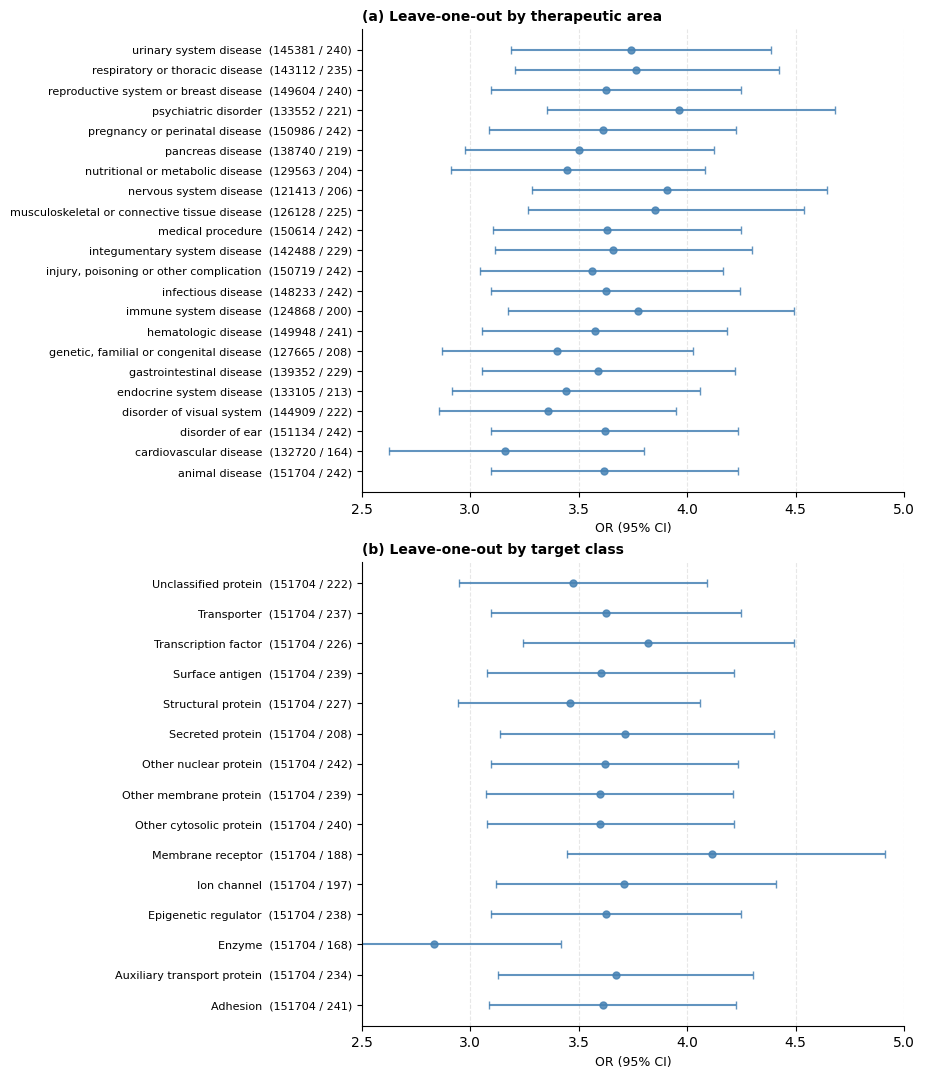

In [18]:
import matplotlib.pyplot as plt
import numpy as np

n_ta = len(df_ta_phase4)
n_tc = len(df_tc_phase4)
fig, (ax_a, ax_b) = plt.subplots(
    2,
    1,
    figsize=(7, n_ta * 0.35 + n_tc * 0.35),
    gridspec_kw={"hspace": 0.15},
)


def forest_plot(ax, df, y_col, panel_label, x_label="OR (95% CI)"):
    df = df.reset_index(drop=True)
    y_pos = np.arange(len(df))
    ax.errorbar(
        df["odds_ratio"],
        y_pos,
        xerr=[df["odds_ratio"] - df["ci_low"], df["ci_high"] - df["odds_ratio"]],
        fmt="o",
        color="steelblue",
        ecolor="steelblue",
        capsize=3,
        markersize=5,
        alpha=0.85,
    )
    ax.axvline(x=1, linestyle="--", color="black", linewidth=0.8)
    ax.set_xlim(2.5, 5)
    ax.set_yticks(y_pos)
    row_labels = [
        f"{row[y_col]}  ({int(row['total_indirect_assoc'])} / {int(row['yes_evid-high_clinphase'])})"
        for _, row in df.iterrows()
    ]
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_title(panel_label, fontsize=10, fontweight="bold", loc="left")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)


forest_plot(
    ax_a,
    df_ta_phase4.sort_values("name"),
    y_col="name",
    panel_label="(a) Leave-one-out by therapeutic area",
)
forest_plot(
    ax_b,
    df_tc_phase4.sort_values("target_class"),
    y_col="target_class",
    panel_label="(b) Leave-one-out by target class",
)

fig.savefig("extended_figure_7.pdf", dpi=300, bbox_inches="tight")
plt.show()
